In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the clean data
df = pd.read_csv('../data/clean_data.csv')

## Univariate Analysis - Numeric Columns
For each numeric column: histogram to see distribution shape, boxplot to see
spread/outliers, and skewness to quantify asymmetry (|skew| > 1 → strongly skewed)

In [31]:
# Baseline numeric summary: count, mean, std, quartiles, min/max
df[['Area', 'Bedrooms', 'Bathrooms', 'Age', 'Price']].describe()

,Area,Bedrooms,Bathrooms,Age,Price
count,300.00000,300.000000,300.000000,300.000000,3.000000e+02
mean,2759.70000,3.033333,2.026667,25.000000,2.488366e+07
std,1297.68143,1.467219,0.792495,14.332646,1.266525e+07
min,520.00000,1.000000,1.000000,0.000000,3.695000e+06
25%,1675.75000,2.000000,1.000000,12.000000,1.527750e+07
50%,2738.00000,3.000000,2.000000,25.500000,2.236500e+07
75%,3801.25000,4.000000,3.000000,36.250000,3.460812e+07
max,4999.00000,5.000000,3.000000,49.000000,5.870000e+07


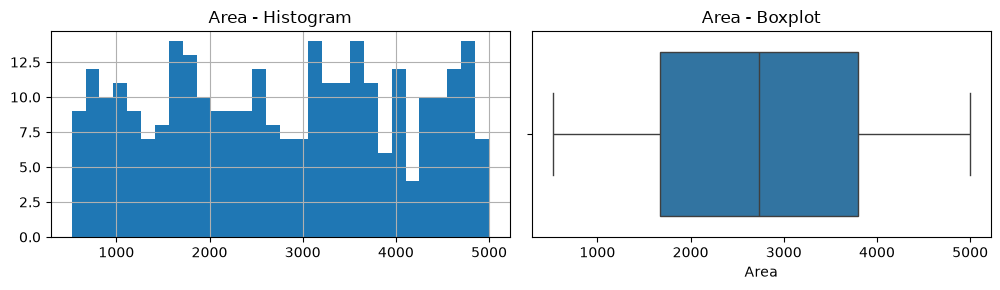

Area: skew = 0.01



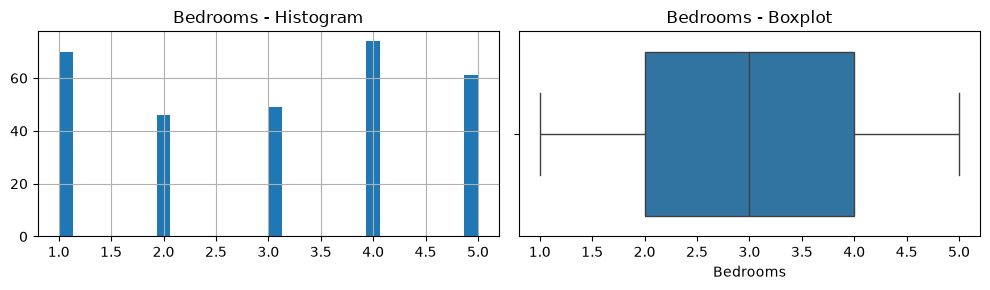

Bedrooms: skew = -0.12



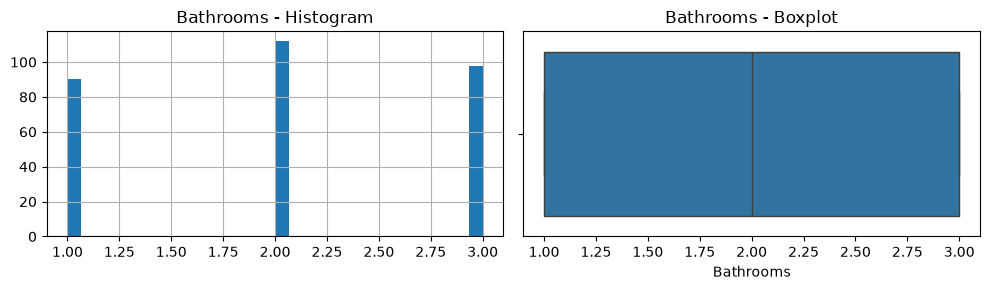

Bathrooms: skew = -0.05



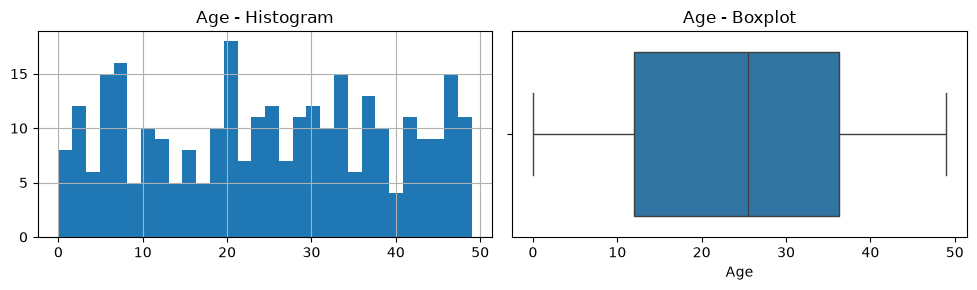

Age: skew = -0.03



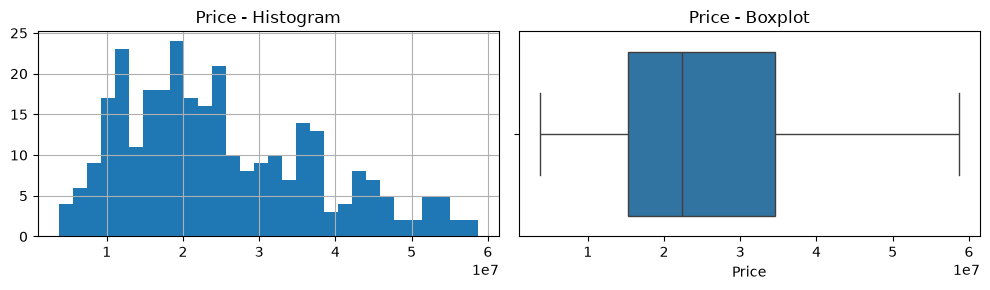

Price: skew = 0.66



In [32]:
# --- Systematic univariate check, all numeric columns ---
# For each column: histogram (shape), boxplot (spread + outliers), skew (asymmetry)
numeric_cols = ['Area', 'Bedrooms', 'Bathrooms', 'Age', 'Price']

for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    df[col].hist(bins=30, ax=axes[0])
    axes[0].set_title(f'{col} - Histogram')
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'{col} - Boxplot')
    plt.tight_layout()
    plt.show()
    print(f"{col}: skew = {df[col].skew():.2f}\n")

## Bivariate Analysis
Examining relationships between pairs of variables: numeric-numeric (correlation),
numeric-categorical (grouped boxplots), and categorical-categorical (crosstab).
Goal: identify which features actually relate to Price.

           Area  Bedrooms  Bathrooms   Age  Price
Area       1.00     -0.00      -0.03 -0.08   0.80
Bedrooms  -0.00      1.00      -0.04 -0.03   0.20
Bathrooms -0.03     -0.04       1.00  0.12  -0.03
Age       -0.08     -0.03       0.12  1.00  -0.13
Price      0.80      0.20      -0.03 -0.13   1.00


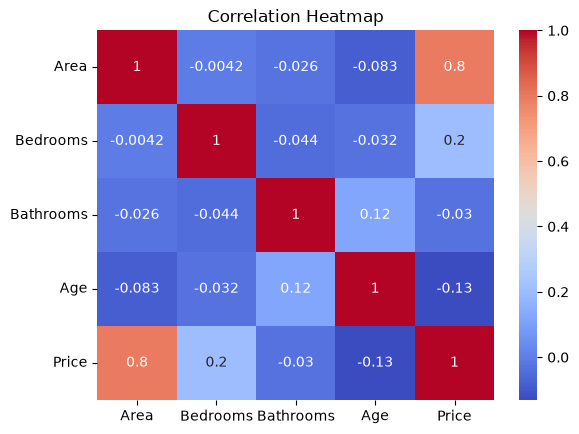

In [33]:
# --- Bivariate Analysis: Numeric vs Numeric ---
# Correlation matrix + heatmap: which numeric features move together?

corr = df[['Area', 'Bedrooms', 'Bathrooms', 'Age', 'Price']].corr()
print(corr.round(2))

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

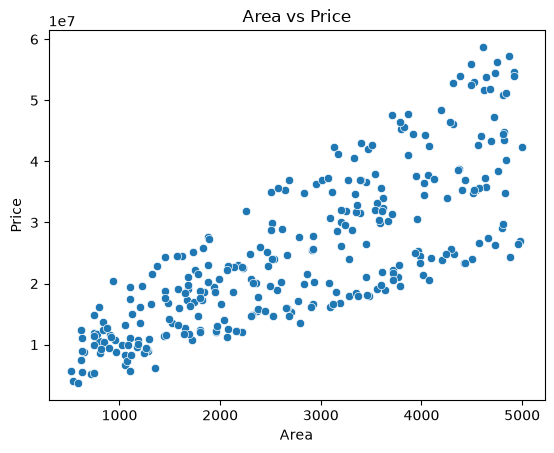

In [34]:
# Scatter plot for the strongest relationship — visualize what the correlation number means
sns.scatterplot(x='Area', y='Price', data=df)
plt.title('Area vs Price')
plt.show()

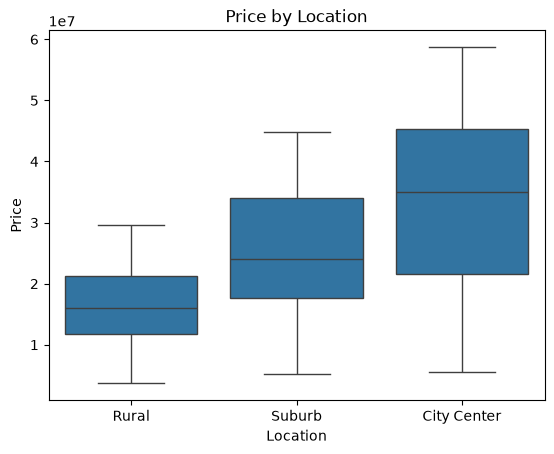

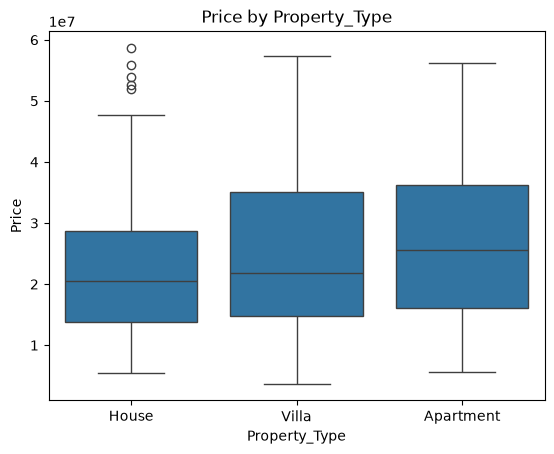

In [35]:
# --- Bivariate Analysis: Numeric vs Categorical ---
# Does Price differ across Location / Property_Type?
sns.boxplot(x='Location', y='Price', data=df)
plt.title('Price by Location')
plt.show()

sns.boxplot(x='Property_Type', y='Price', data=df)
plt.title('Price by Property_Type')
plt.show()

In [36]:
# --- Bivariate Analysis: Categorical vs Categorical ---
# Are certain property types concentrated in certain locations?
pd.crosstab(df['Location'], df['Property_Type'])

Property_Type,Apartment,House,Villa
Location,,,
City Center,28,37,32
Rural,31,34,33
Suburb,32,36,37


## Key Findings
- Area is the strongest numeric predictor of Price (r = 0.80)
- Location has a clear ordered effect on Price: City Center > Suburb > Rural
- Property_Type, Bedrooms, Bathrooms, and Age show weak individual correlation with Price